# Random Forest

- It is a powerful supervised machine learning algorithm that combines the predictions of multiple decision trees to create a more accurate and stable model.
- It is considered an ensemble learning method because it uses a "forest" of diverse models rather than relying on just one.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [2]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5, n_clusters_per_class=1)

In [3]:
df = pd.DataFrame(X, columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-2.084339,0.595799,-0.531824,0.474148,-1.011901,0
1,1.627320,-0.831479,3.795188,-2.618742,-0.848173,0
2,1.101703,-2.040523,-1.864075,0.322580,0.200881,1
3,3.066157,-1.824705,1.247762,-2.221787,-2.035170,0
4,3.630268,1.149793,1.449929,-1.657858,-1.840870,0


### Function for Row Sampling

In [4]:
def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]), replace=True)

### Function for Feature/Column Sampling

In [23]:
import random
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1], int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

### Function for Combined (Row+Feature) Sampling

In [24]:
def combined_sample(df, row_percent, col_percent):
  new_df = sample_rows(df, row_percent)
  return sample_features(new_df, col_percent)

In [7]:
#sample_rows(df,0.1)

### Subsets of Data for Row Sampling

In [8]:
df1 = sample_rows(df,0.1)

In [9]:
df2 = sample_rows(df,0.1)

In [10]:
df3 = sample_rows(df,0.1)

In [11]:
df3.shape

(10, 6)

In [12]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [13]:
clf1.fit(df1.iloc[:,0:5],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:5],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:5],df3.iloc[:,-1])

DecisionTreeClassifier()

In [14]:
from sklearn.tree import plot_tree

[Text(0.5, 0.75, 'x[2] <= 0.328\ngini = 0.42\nsamples = 10\nvalue = [7, 3]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.625, 0.5, '  False')]

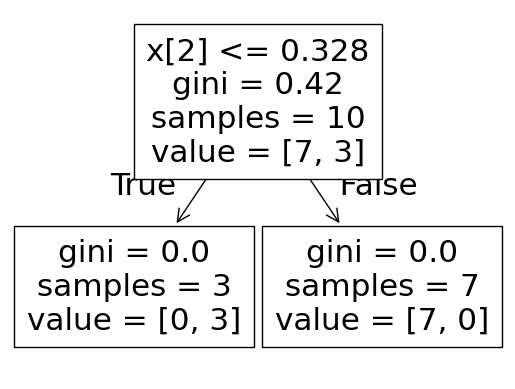

In [15]:
plot_tree(clf1)

[Text(0.6, 0.8333333333333334, 'x[3] <= 0.642\ngini = 0.42\nsamples = 10\nvalue = [3, 7]'),
 Text(0.4, 0.5, 'x[1] <= 1.189\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.7, 0.6666666666666667, '  False')]

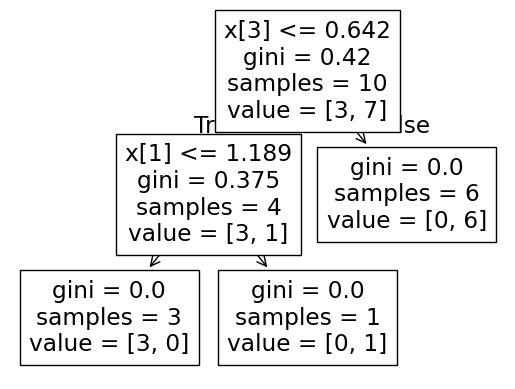

In [16]:
plot_tree(clf2)

[Text(0.6666666666666666, 0.875, 'x[1] <= 0.429\ngini = 0.42\nsamples = 10\nvalue = [3, 7]'),
 Text(0.5, 0.625, 'x[1] <= -0.851\ngini = 0.219\nsamples = 8\nvalue = [1, 7]'),
 Text(0.5833333333333333, 0.75, 'True  '),
 Text(0.3333333333333333, 0.375, 'x[0] <= 0.617\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.16666666666666666, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.5, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.6666666666666666, 0.375, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.8333333333333334, 0.625, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.75, 0.75, '  False')]

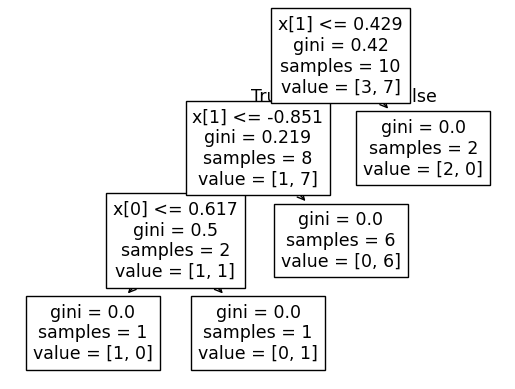

In [17]:
plot_tree(clf3)

In [20]:
clf1.predict(np.array([-2.084339,	0.595799,	-0.531824,	0.474148,	-1.011901]).reshape(1,5))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [21]:
clf2.predict(np.array([-2.084339,	0.595799,	-0.531824,	0.474148,	-1.011901]).reshape(1,5))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [22]:
clf3.predict(np.array([-2.084339,	0.595799,	-0.531824,	0.474148,	-1.011901]).reshape(1,5))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

### Subsets of Data for Column Sampling

In [35]:
(sample_features(df,0.8)).head()

/tmp/ipykernel_4066/3668654637.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


,col3,col2,col4,col1,target
0,-0.531824,0.595799,0.474148,-2.084339,0
1,3.795188,-0.831479,-2.618742,1.627320,0
2,-1.864075,-2.040523,0.322580,1.101703,1
3,1.247762,-1.824705,-2.221787,3.066157,0
4,1.449929,1.149793,-1.657858,3.630268,0


In [27]:
dc1 = sample_features(df,0.8)
dc2 = sample_features(df,0.8)
dc3 = sample_features(df,0.8)
dc3.shape

/tmp/ipykernel_4066/3668654637.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']
/tmp/ipykernel_4066/3668654637.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']
/tmp/ipykernel_4066/3668654637.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/in

(100, 5)

In [34]:
print(dc1.columns)
print(dc2.columns)
print(dc3.columns)

Index(['col5', 'col1', 'col3', 'col4', 'target'], dtype='object')
Index(['col5', 'col2', 'col1', 'col4', 'target'], dtype='object')
Index(['col4', 'col2', 'col5', 'col3', 'target'], dtype='object')


In [28]:
from sklearn.tree import DecisionTreeClassifier
cf1 = DecisionTreeClassifier()
cf2 = DecisionTreeClassifier()
cf3 = DecisionTreeClassifier()

In [29]:
cf1.fit(dc1.iloc[:,0:4],dc1.iloc[:,-1])
cf2.fit(dc2.iloc[:,0:4],dc2.iloc[:,-1])
cf3.fit(dc3.iloc[:,0:4],dc3.iloc[:,-1])

DecisionTreeClassifier()

In [30]:
from sklearn.tree import plot_tree

[Text(0.4027777777777778, 0.9444444444444444, 'x[3] <= -0.276\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.2222222222222222, 0.8333333333333334, 'x[2] <= -0.087\ngini = 0.231\nsamples = 45\nvalue = [39, 6]'),
 Text(0.3125, 0.8888888888888888, 'True  '),
 Text(0.16666666666666666, 0.7222222222222222, 'x[0] <= -1.789\ngini = 0.497\nsamples = 13\nvalue = [7, 6]'),
 Text(0.1111111111111111, 0.6111111111111112, 'x[2] <= -0.305\ngini = 0.346\nsamples = 9\nvalue = [7, 2]'),
 Text(0.05555555555555555, 0.5, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.16666666666666666, 0.5, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.2222222222222222, 0.6111111111111112, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.2777777777777778, 0.7222222222222222, 'gini = 0.0\nsamples = 32\nvalue = [32, 0]'),
 Text(0.5833333333333334, 0.8333333333333334, 'x[1] <= -0.691\ngini = 0.32\nsamples = 55\nvalue = [11, 44]'),
 Text(0.4930555555555556, 0.8888888888888888, '  False'),
 Text(0.3888888

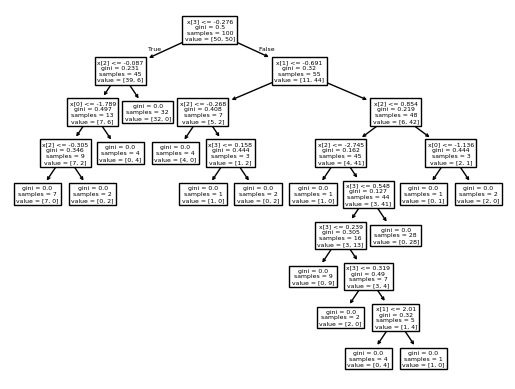

In [31]:
plot_tree(cf1)

[Text(0.3977272727272727, 0.9444444444444444, 'x[3] <= -0.276\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.13636363636363635, 0.8333333333333334, 'x[1] <= -1.186\ngini = 0.231\nsamples = 45\nvalue = [39, 6]'),
 Text(0.26704545454545453, 0.8888888888888888, 'True  '),
 Text(0.09090909090909091, 0.7222222222222222, 'gini = 0.0\nsamples = 21\nvalue = [21, 0]'),
 Text(0.18181818181818182, 0.7222222222222222, 'x[2] <= 0.486\ngini = 0.375\nsamples = 24\nvalue = [18, 6]'),
 Text(0.09090909090909091, 0.6111111111111112, 'x[1] <= 0.345\ngini = 0.48\nsamples = 5\nvalue = [2, 3]'),
 Text(0.045454545454545456, 0.5, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.13636363636363635, 0.5, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.2727272727272727, 0.6111111111111112, 'x[1] <= -1.071\ngini = 0.266\nsamples = 19\nvalue = [16, 3]'),
 Text(0.22727272727272727, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.3181818181818182, 0.5, 'x[1] <= -0.51\ngini = 0.198\nsamples = 1

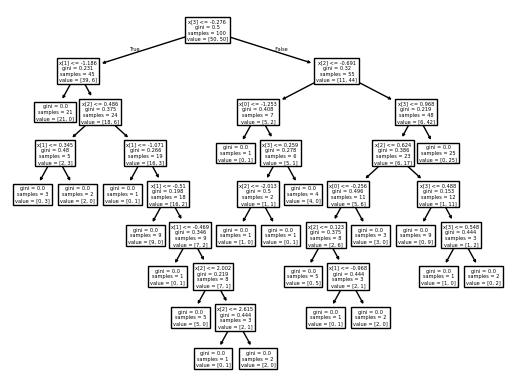

In [32]:
plot_tree(cf2)

[Text(0.5, 0.9, 'x[0] <= -0.276\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.3076923076923077, 0.7, 'x[3] <= -0.087\ngini = 0.231\nsamples = 45\nvalue = [39, 6]'),
 Text(0.40384615384615385, 0.8, 'True  '),
 Text(0.23076923076923078, 0.5, 'x[2] <= -1.789\ngini = 0.497\nsamples = 13\nvalue = [7, 6]'),
 Text(0.15384615384615385, 0.3, 'x[3] <= -0.305\ngini = 0.346\nsamples = 9\nvalue = [7, 2]'),
 Text(0.07692307692307693, 0.1, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.23076923076923078, 0.1, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.3076923076923077, 0.3, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.38461538461538464, 0.5, 'gini = 0.0\nsamples = 32\nvalue = [32, 0]'),
 Text(0.6923076923076923, 0.7, 'x[1] <= -0.099\ngini = 0.32\nsamples = 55\nvalue = [11, 44]'),
 Text(0.5961538461538461, 0.8, '  False'),
 Text(0.5384615384615384, 0.5, 'x[3] <= -2.745\ngini = 0.18\nsamples = 40\nvalue = [4, 36]'),
 Text(0.46153846153846156, 0.3, 'gini = 0.0\nsamples = 2

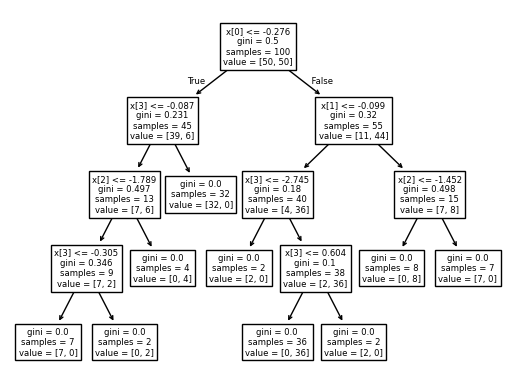

In [33]:
plot_tree(cf3)

In [36]:
cf1.predict(np.array([-1.864075,	-2.040523,	0.322580,	1.101703]).reshape(1,4))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [37]:
cf2.predict(np.array([-1.864075,	-2.040523,	0.322580,	1.101703]).reshape(1,4))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [38]:
cf3.predict(np.array([-1.864075,	-2.040523,	0.322580,	1.101703]).reshape(1,4))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

### Datasets for Combined Sampling

In [41]:
combined_sample(df,0.5,0.5).head()

/tmp/ipykernel_4066/3668654637.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


,col2,col1,target
98,-0.584350,1.224037,1
33,0.204868,1.388070,1
5,0.033370,2.288801,1
52,-0.727499,4.144473,1
42,-2.338964,3.259207,0


In [42]:
dcs1 = combined_sample(df,0.5,0.5)
dcs2 = combined_sample(df,0.5,0.5)
dcs3 = combined_sample(df,0.5,0.5)
dcs3.shape

/tmp/ipykernel_4066/3668654637.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']
/tmp/ipykernel_4066/3668654637.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']
/tmp/ipykernel_4066/3668654637.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/in

(50, 3)

In [43]:
print(dcs1.columns)
print(dcs2.columns)
print(dcs3.columns)

Index(['col3', 'col5', 'target'], dtype='object')
Index(['col3', 'col1', 'target'], dtype='object')
Index(['col4', 'col3', 'target'], dtype='object')


In [44]:
from sklearn.tree import DecisionTreeClassifier
cfc1 = DecisionTreeClassifier()
cfc2 = DecisionTreeClassifier()
cfc3 = DecisionTreeClassifier()

In [45]:
cfc1.fit(dcs1.iloc[:,0:2],dcs1.iloc[:,-1])
cfc2.fit(dcs2.iloc[:,0:2],dcs2.iloc[:,-1])
cfc3.fit(dcs3.iloc[:,0:2],dcs3.iloc[:,-1])

DecisionTreeClassifier()

In [46]:
from sklearn.tree import plot_tree

[Text(0.4444444444444444, 0.9166666666666666, 'x[0] <= 0.459\ngini = 0.497\nsamples = 50\nvalue = [27, 23]'),
 Text(0.3333333333333333, 0.75, 'x[0] <= -2.093\ngini = 0.358\nsamples = 30\nvalue = [7, 23]'),
 Text(0.38888888888888884, 0.8333333333333333, 'True  '),
 Text(0.2222222222222222, 0.5833333333333334, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.4444444444444444, 0.5833333333333334, 'x[1] <= -2.506\ngini = 0.204\nsamples = 26\nvalue = [3, 23]'),
 Text(0.2222222222222222, 0.4166666666666667, 'x[1] <= -3.157\ngini = 0.5\nsamples = 4\nvalue = [2, 2]'),
 Text(0.1111111111111111, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.3333333333333333, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.6666666666666666, 0.4166666666666667, 'x[0] <= -0.443\ngini = 0.087\nsamples = 22\nvalue = [1, 21]'),
 Text(0.5555555555555556, 0.25, 'gini = 0.0\nsamples = 15\nvalue = [0, 15]'),
 Text(0.7777777777777778, 0.25, 'x[0] <= -0.268\ngini = 0.245\nsamples = 7\nvalue = [1, 6]

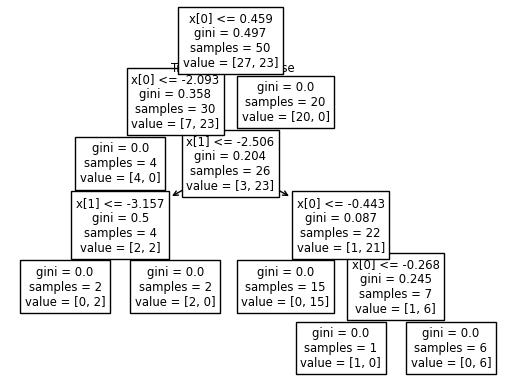

In [47]:
plot_tree(cfc1)

[Text(0.46153846153846156, 0.9545454545454546, 'x[0] <= 0.399\ngini = 0.499\nsamples = 50\nvalue = [24, 26]'),
 Text(0.38461538461538464, 0.8636363636363636, 'x[1] <= 2.952\ngini = 0.382\nsamples = 35\nvalue = [9, 26]'),
 Text(0.42307692307692313, 0.9090909090909092, 'True  '),
 Text(0.3076923076923077, 0.7727272727272727, 'x[1] <= -1.918\ngini = 0.334\nsamples = 33\nvalue = [7, 26]'),
 Text(0.23076923076923078, 0.6818181818181818, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.38461538461538464, 0.6818181818181818, 'x[0] <= -1.044\ngini = 0.305\nsamples = 32\nvalue = [6, 26]'),
 Text(0.15384615384615385, 0.5909090909090909, 'x[1] <= 2.418\ngini = 0.111\nsamples = 17\nvalue = [1, 16]'),
 Text(0.07692307692307693, 0.5, 'gini = 0.0\nsamples = 14\nvalue = [0, 14]'),
 Text(0.23076923076923078, 0.5, 'x[1] <= 2.48\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.15384615384615385, 0.4090909090909091, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.3076923076923077, 0.4090909090

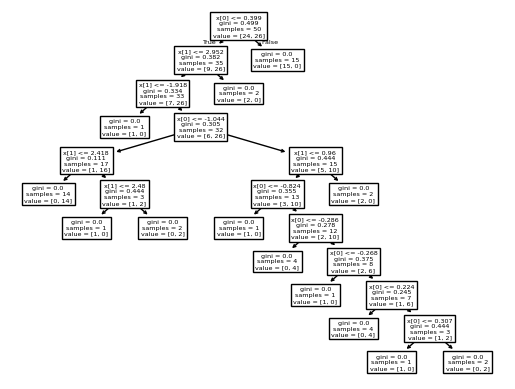

In [49]:
plot_tree(cfc2)

[Text(0.45454545454545453, 0.9, 'x[0] <= -0.276\ngini = 0.493\nsamples = 50\nvalue = [22.0, 28.0]'),
 Text(0.2727272727272727, 0.7, 'x[1] <= -0.978\ngini = 0.18\nsamples = 20\nvalue = [18, 2]'),
 Text(0.36363636363636365, 0.8, 'True  '),
 Text(0.18181818181818182, 0.5, 'x[1] <= -1.95\ngini = 0.5\nsamples = 4\nvalue = [2, 2]'),
 Text(0.09090909090909091, 0.3, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.2727272727272727, 0.3, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.36363636363636365, 0.5, 'gini = 0.0\nsamples = 16\nvalue = [16, 0]'),
 Text(0.6363636363636364, 0.7, 'x[1] <= -1.93\ngini = 0.231\nsamples = 30\nvalue = [4, 26]'),
 Text(0.5454545454545454, 0.8, '  False'),
 Text(0.5454545454545454, 0.5, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.7272727272727273, 0.5, 'x[1] <= -0.568\ngini = 0.071\nsamples = 27\nvalue = [1, 26]'),
 Text(0.6363636363636364, 0.3, 'gini = 0.0\nsamples = 19\nvalue = [0, 19]'),
 Text(0.8181818181818182, 0.3, 'x[1] <= -0.489\ngini = 0.2

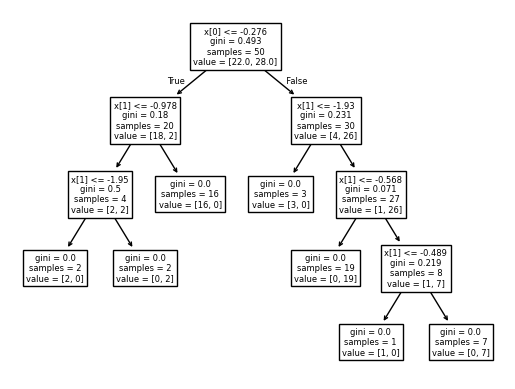

In [50]:
plot_tree(cfc3)

In [51]:
cfc1.predict(np.array([-2.338964, 3.259207]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [52]:
cfc2.predict(np.array([-2.338964, 3.259207]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [53]:
cfc3.predict(np.array([-2.338964, 3.259207]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

- Reduces Overfitting: Single decision trees often overfit by learning training data too perfectly; Random Forest corrects this by averaging multiple viewpoints.

- Handles High Dimensionality: It performs well even when there are many input features and can identify which ones are most important for prediction.

- Robustness: It is less sensitive to noise and outliers than a single decision tree.

- Versatility: It can be used for both predicting categories (Classification) and numerical values (Regression).